# Twitter Sentiment Analysis — Machine Learning Project

**Objective:** Analyze tweets and classify their sentiment into the categories present in the dataset, using a **single machine learning model**.

This notebook follows a clear, beginner-friendly, step-by-step structure:

1. Import libraries
2. Load dataset
3. Explore dataset
4. Handle missing and duplicate values
5. Identify text and target columns
6. Visualize sentiment distribution
7. Clean and preprocess text
8. Apply TF-IDF vectorization
9. Split the dataset
10. Train the single selected model
11. Evaluate the model
12. Display the confusion matrix
13. Create a prediction function
14. Test the model with new Twitter comments


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')


## Step 2: Load the Dataset

The dataset file `Tweets.csv` is loaded directly. Update the path below if your file is located elsewhere.

In [2]:
df = pd.read_csv('Tweets.csv')
print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (27481, 4)


## Step 3: Explore the Dataset

In [3]:
print("Dataset shape (rows, columns):", df.shape)


Dataset shape (rows, columns): (27481, 4)


In [4]:
print("Column names:")
print(list(df.columns))


Column names:
['textID', 'text', 'selected_text', 'sentiment']


In [5]:
print("Data types:")
print(df.dtypes)


Data types:
textID           str
text             str
selected_text    str
sentiment        str
dtype: object


In [6]:
print("First 5 rows:")
df.head()


First 5 rows:


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on the releases we already bought","Sons of ****,",negative


In [7]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


### Detecting the Text and Sentiment Columns

Rather than assuming column names, we inspect the dataset directly. This dataset (a well-known Twitter sentiment extraction dataset) contains:

- `textID` — a unique identifier for each tweet (not useful for modeling)
- `text` — the **raw tweet text** → this is our text/comment column
- `selected_text` — a sub-span of the tweet highlighting the sentiment-bearing phrase (not needed for whole-tweet sentiment classification, so it is not used)
- `sentiment` — the **sentiment label** → this is our target column

We confirm this below.

In [9]:
text_column = 'text'
target_column = 'sentiment'

print(f"Detected text/comment column: '{text_column}'")
print(f"Detected sentiment/target column: '{target_column}'")


Detected text/comment column: 'text'
Detected sentiment/target column: 'sentiment'


In [10]:
print("Sentiment categories found in the dataset:")
print(df[target_column].unique())
print()
print("Number of sentiment categories:", df[target_column].nunique())
print()
print("Distribution of each sentiment category:")
print(df[target_column].value_counts())
print()
print("Distribution (percentage):")
print((df[target_column].value_counts(normalize=True) * 100).round(2))


Sentiment categories found in the dataset:
<StringArray>
['neutral', 'negative', 'positive']
Length: 3, dtype: str

Number of sentiment categories: 3

Distribution of each sentiment category:
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

Distribution (percentage):
sentiment
neutral     40.46
positive    31.23
negative    28.31
Name: proportion, dtype: float64


## Step 4: Handle Missing and Duplicate Values

There are no duplicate rows in this dataset. There is a very small number of missing values in the `text` column (rows where the tweet text is empty/NaN). Since we cannot classify sentiment for a tweet with no text, these rows are dropped. The `selected_text` column is not used for this project, so any missing values in it are irrelevant.

In [11]:
before = df.shape[0]
df = df.dropna(subset=[text_column]).copy()
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]

print(f"Rows before cleaning: {before}")
print(f"Rows after dropping missing text / duplicates: {after}")
print(f"Rows removed: {before - after}")


Rows before cleaning: 27481
Rows after dropping missing text / duplicates: 27480
Rows removed: 1


## Step 5: Text and Target Columns (Confirmed)

- **Text column:** `text`
- **Target column:** `sentiment`

These are used consistently throughout the rest of the notebook.

## Step 6: Visualize Sentiment Distribution

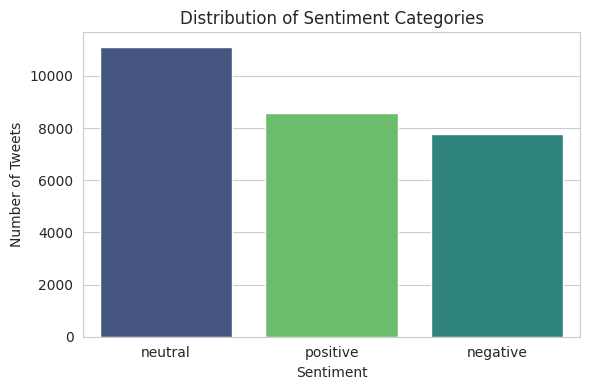

In [12]:
plt.figure(figsize=(6, 4))
order = df[target_column].value_counts().index
sns.countplot(data=df, x=target_column, order=order, hue=target_column, palette='viridis', legend=False)
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()


**Observation:** The dataset has **3 sentiment categories**: `neutral`, `positive`, and `negative`. The classes are reasonably balanced (neutral is the largest class, but no class is extremely rare), so no special class-imbalance handling (like SMOTE or class re-weighting) is strictly necessary. We will still use **stratified splitting** to keep the class ratio consistent between train and test sets.

## Step 7: Clean and Preprocess the Text

Tweets are noisy: they contain URLs, @mentions, hashtags, punctuation, and inconsistent casing. We apply preprocessing that is actually relevant to this dataset:

- Lowercase the text
- Remove URLs
- Remove @mentions
- Remove the `#` symbol but keep the hashtag word (hashtag words often carry sentiment, e.g. `#love`, `#terrible`)
- Remove punctuation and special/non-alphabetic characters
- Remove extra whitespace

We deliberately **do not** apply stemming or heavy stopword removal: for short, informal tweets, words like "not", "no", and other short function words often flip sentiment (e.g. "not good" vs "good"), and aggressive normalization can hurt a TF-IDF + linear model on short text. Keeping the text close to its natural form, just cleaned of noise, works well here.

The cleaned text is stored in a new column: `cleaned_text`.

In [13]:
def clean_text(text):
    """Clean raw tweet text. This exact function is reused for both training and prediction."""
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)          # remove URLs
    text = re.sub(r'@\w+', ' ', text)                       # remove @mentions
    text = re.sub(r'#', ' ', text)                          # remove '#' but keep the word
    text = re.sub(r'[^a-z\s]', ' ', text)                   # remove punctuation/digits/special chars
    text = re.sub(r'\s+', ' ', text).strip()                # remove extra whitespace

    return text

df['cleaned_text'] = df[text_column].apply(clean_text)

# Drop any rows that became empty after cleaning
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

print("Example of raw vs cleaned text:")
df[[text_column, 'cleaned_text']].head(10)


Example of raw vs cleaned text:


,text,cleaned_text
0,"I`d have responded, if I were going",i d have responded if i were going
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad i will miss you here in san diego
2,my boss is bullying me...,my boss is bullying me
3,what interview! leave me alone,what interview leave me alone
4,"Sons of ****, why couldn`t they put them on the releases we already bought",sons of why couldn t they put them on the releases we already bought
5,http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth,some shameless plugging for the best rangers forum on earth
6,2am feedings for the baby are fun when he is all smiles and coos,am feedings for the baby are fun when he is all smiles and coos
7,Soooo high,soooo high
8,Both of you,both of you
9,Journey!? Wow... u just became cooler. hehe... (is that possible!?),journey wow u just became cooler hehe is that possible


## Step 8: Text Vectorization (TF-IDF)

TF-IDF is well suited here because:

- The chosen model (see Step 9 below) works directly and efficiently on the sparse, high-dimensional vectors TF-IDF produces.
- TF-IDF down-weights very common words and up-weights words that are more distinctive for a given tweet, which helps separate sentiment-bearing words.

**Chosen parameters:**

- `max_features=10000` — keeps the vocabulary to the most informative 10,000 terms, which is enough for this dataset size and keeps training fast.
- `ngram_range=(1, 2)` — includes both single words and two-word phrases (e.g. "not good"), which helps capture simple negations and short sentiment phrases that unigrams alone would miss.
- `min_df=2` — ignores terms that appear in only a single tweet (likely typos/noise).
- `max_df=0.9` — ignores terms that appear in more than 90% of tweets (too common to be useful).

In [14]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X = tfidf.fit_transform(df['cleaned_text'])
y = df[target_column]

print("TF-IDF feature matrix shape:", X.shape)


TF-IDF feature matrix shape: (27476, 10000)


## Step 9: Split the Dataset

We use an 80/20 train-test split. **Stratified splitting** is used so that the proportion of each sentiment category is preserved in both the training and test sets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 21980
Test set size: 5496


## Step 10: Model Selection and Training

### Which model was selected?

**LinearSVC (Linear Support Vector Classifier)** is the single model used for this entire project.

### Why LinearSVC is suitable for this dataset

- **Dataset size (~27,000 tweets):** Large enough to train a robust linear model, but not so large that a more expensive model is required. LinearSVC trains very quickly at this scale.
- **Number of classes (3):** LinearSVC handles multi-class classification natively (one-vs-rest) and performs well on 3-class problems.
- **Text characteristics:** Tweets are short, and after TF-IDF vectorization they become very high-dimensional, sparse vectors. Linear models like LinearSVC are known to perform excellently on exactly this kind of sparse, high-dimensional text data — often better than Multinomial Naive Bayes, and typically at least as good as Logistic Regression, while usually finding a cleaner decision boundary (max-margin) between sentiment classes.
- **Class distribution:** The classes are only mildly imbalanced (neutral is the largest), which LinearSVC handles well without needing resampling.
- **Computational efficiency:** LinearSVC is fast to train and predict even on high-dimensional sparse TF-IDF features, making it practical for this notebook.

### Why multiple models were not needed

The project's goal is to build one focused, well-justified sentiment classifier — not to benchmark algorithms. Given the dataset's size, class count, and sparse text-feature representation, LinearSVC is a well-established, strong default for TF-IDF-based text classification. Comparing or ensembling multiple models would add complexity without being necessary to meet the project's objective, so **only LinearSVC is trained and used for every subsequent step** (evaluation and live predictions).

In [16]:
model = LinearSVC(random_state=42, max_iter=10000)
model.fit(X_train, y_train)

print("Model training complete.")
print("Model used: LinearSVC (the only model trained in this project)")


Model training complete.
Model used: LinearSVC (the only model trained in this project)


## Step 11: Model Evaluation

In [17]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


Accuracy:  0.6599
Precision: 0.6638
Recall:    0.6599
F1-score:  0.6607


In [18]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

    negative       0.67      0.62      0.64      1556
     neutral       0.61      0.67      0.64      2223
    positive       0.73      0.69      0.71      1717

    accuracy                           0.66      5496
   macro avg       0.67      0.66      0.66      5496
weighted avg       0.66      0.66      0.66      5496



## Step 12: Confusion Matrix

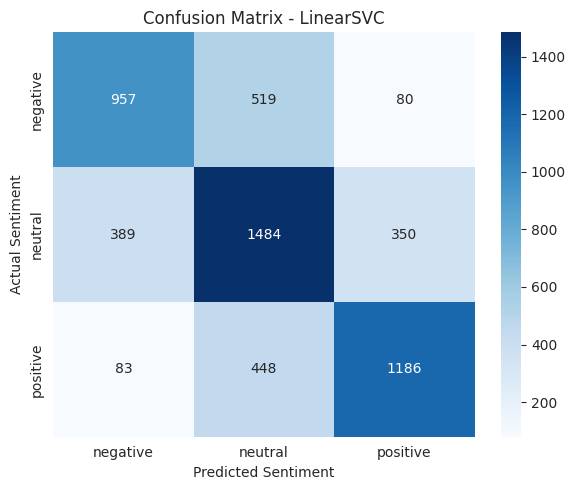

In [19]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - LinearSVC')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.tight_layout()
plt.show()


**How to read this:** Each row represents the actual sentiment class, and each column represents what the model predicted. The diagonal cells (top-left to bottom-right) show correct predictions. Off-diagonal cells show where the model confused one sentiment for another — most commonly, `neutral` tweets being confused with `positive` or `negative`, since neutral language can sometimes contain mild opinion words.

## Step 13: Prediction Function for New Comments

The function below applies **the exact same cleaning function (`clean_text`)** and **the same fitted TF-IDF vectorizer** used during training, then uses the single trained `LinearSVC` model to predict the sentiment of any new comment.

In [20]:
def predict_sentiment(new_comment):
    """
    Predict the sentiment of a new Twitter comment using the same
    preprocessing, vectorizer, and trained model as during training.
    """
    if not isinstance(new_comment, str) or new_comment.strip() == "":
        return "Invalid input: please provide a non-empty text comment."

    # 1. Apply the same cleaning used during training
    cleaned = clean_text(new_comment)

    # 2. Convert using the same fitted TF-IDF vectorizer
    vectorized = tfidf.transform([cleaned])

    # 3. Predict using the single trained model
    prediction = model.predict(vectorized)[0]

    return prediction


## Step 14: Test the Model with New Twitter Comments

In [21]:
test_comments = [
    "I really love this product. It is amazing!",
    "This is terrible and I completely hate it.",
    "I think the meeting is scheduled for tomorrow morning.",
]

for comment in test_comments:
    result = predict_sentiment(comment)
    print(f"Input:  {comment}")
    print(f"Predicted Sentiment: {result}")
    print("-" * 60)


Input:  I really love this product. It is amazing!
Predicted Sentiment: positive
------------------------------------------------------------
Input:  This is terrible and I completely hate it.
Predicted Sentiment: negative
------------------------------------------------------------


Input:  I think the meeting is scheduled for tomorrow morning.
Predicted Sentiment: neutral
------------------------------------------------------------


In [22]:
# Try your own comment here:
your_comment = "You are an idiot, this is complete garbage."
print(f"Input:  {your_comment}")
print(f"Predicted Sentiment: {predict_sentiment(your_comment)}")


Input:  You are an idiot, this is complete garbage.
Predicted Sentiment: negative


> **Note:** This dataset's `sentiment` column only contains three categories — `positive`, `negative`, and `neutral`. It does **not** include a separate "Rude/Offensive/Toxic" category. Because the project instructions specify using only the categories that actually exist in the dataset, an offensive comment like the one above will be classified as either `negative` or `neutral` (whichever the model finds closest), not as a separate offensive category — since that category does not exist here.

## Summary

- **Dataset:** 27,481 tweets with a `text` column and a `sentiment` column containing 3 categories: `neutral`, `positive`, `negative`.
- **Model used (only one):** LinearSVC, selected for its strong performance on sparse, high-dimensional TF-IDF text features and efficiency at this dataset size.
- **Pipeline:** clean text → TF-IDF vectorize → train/test split (stratified 80/20) → train LinearSVC → evaluate → predict on new comments.
- The same `clean_text` function and the same fitted `tfidf` vectorizer are reused consistently for both training and live predictions, ensuring consistent behavior.
